In [1]:
import parcels
import numpy as np
from datetime import timedelta
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import os

def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:-1]=0.5*(var_u[:,1:]+var_u[:,:-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:-1,:]=0.5*(var_v[1:,:]+var_v[:-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:-1]=0.5*(var_u[:,:,1:]+var_u[:,:,:-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:-1,:]=0.5*(var_v[:,1:,:]+var_v[:,:-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,-1,:]=var_rho[:,-2,:]
    return var_rho

def spheric_dist(lat1, lat2, lon1, lon2):
    """
    Compute the spherical distance between two points on Earth.
    
    Parameters:
    lat1, lat2 : array-like
        Latitude of the two points (in degrees).
    lon1, lon2 : array-like
        Longitude of the two points (in degrees).
    
    Returns:
    dist : array-like
        The spherical distance between the points (in meters).
    """
    
    # Earth radius in meters
    R = 6367442.76
    
    # Determine proper longitudinal shift
    l = np.abs(lon2 - lon1)
    l[l >= 180] = 360 - l[l >= 180]
    
    # Convert decimal degrees to radians
    deg2rad = np.pi / 180
    lat1 = lat1 * deg2rad
    lat2 = lat2 * deg2rad
    l = l * deg2rad
    
    # Compute the distances
    dist = R * np.arcsin(np.sqrt(((np.sin(l) * np.cos(lat2)) ** 2) + 
                                 ((np.sin(lat2) * np.cos(lat1)) - 
                                  (np.sin(lat1) * np.cos(lat2) * np.cos(l))) ** 2))
    
    return dist

def spheric_dist_one(lat1, lat2, lon1, lon2):
    """计算两个经纬度点之间的球面距离（标量版）"""
    # 处理经度差
    l = np.abs(lon2 - lon1)
    if l >= 180:
        l = 360 - l
    
    # 转换为弧度
    deg2rad = np.pi / 180
    lat1_rad = lat1 * deg2rad
    lat2_rad = lat2 * deg2rad
    l_rad = l * deg2rad
    
    # 球面距离公式
    distance = 6371 * np.arccos(
        np.sin(lat1_rad) * np.sin(lat2_rad) + 
        np.cos(lat1_rad) * np.cos(lat2_rad) * np.cos(l_rad)
    )
    return distance
def transunit_spher2flat(u,v,lat):
    v1=v*1852*60
    u1=u*1852*60*np.cos(lat*np.pi/180)
    return u1,v1

def get_velgradient(cg,pm,pn):
    u1=u2rho_3d(np.squeeze(cg['u'].values))
    v1=v2rho_3d(np.squeeze(cg['v'].values))
    ux=u2rho_3d((u1[:,:,1:]-u1[:,:,:-1])/np.tile(0.5*(1/pm[:,1:]+1/pm[:,:-1]),[u1.shape[0],1,1]))
    vx=u2rho_3d((v1[:,:,1:]-v1[:,:,:-1])/np.tile(0.5*(1/pm[:,1:]+1/pm[:,:-1]),[u1.shape[0],1,1]))
    uy=v2rho_3d((u1[:,1:,:]-u1[:,:-1,:])/np.tile(0.5*(1/pn[1:,:]+1/pn[:-1,:]),[u1.shape[0],1,1]))
    vy=v2rho_3d((v1[:,1:,:]-v1[:,:-1,:])/np.tile(0.5*(1/pn[1:,:]+1/pn[:-1,:]),[u1.shape[0],1,1]))
    return ux,vx,uy,vy

def get_traj(w):
    lon=w['lon'].values
    lat=w['lat'].values
    return lon,lat


In [2]:
grid=xr.open_dataset('/meddy/simingzhang/Data/RB_iceland_data/niskin2km_500m_grd.nc')
cgw=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/wavecase_modified_vel_cg_kaiser_corr.nc')
cgnw=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/nowavecase_modified_vel_cg_kaiser_corr.nc')

# p1e4=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P10000T20.0seconds.nc')
# p6e4=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P62500T20.0seconds.nc')
# lon1e4=p1e4['lon'].values
# lat1e4=p1e4['lat'].values
# lon6e4=p6e4['lon'].values
# lat6e4=p6e4['lat'].values

In [3]:
lonr=cgw['lon_rho'].values
latr=cgw['lat_rho'].values
pm=grid['pm'].values
pn=grid['pn'].values
f=grid['f'].values
ux_w,vx_w,uy_w,vy_w=get_velgradient(cgw,pm,pn)
ux_nw,vx_nw,uy_nw,vy_nw=get_velgradient(cgnw,pm,pn)

In [4]:
Ro_w=(vx_w-uy_w)/np.tile(f,[ux_w.shape[0],1,1])
divof_w=(ux_w+vy_w)/np.tile(f,[ux_w.shape[0],1,1])
Ro_nw=(vx_nw-uy_nw)/np.tile(f,[ux_w.shape[0],1,1])
divof_nw=(ux_nw+vy_nw)/np.tile(f,[ux_w.shape[0],1,1])

# plt

In [5]:
tindex=0
lonmin=np.nanmin(lonr)
latmin=np.nanmin(latr)
lonmax=np.nanmax(lonr)
latmax=np.nanmax(latr)

/tmp/ipykernel_1420684/2896661677.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
/tmp/ipykernel_1420684/2896661677.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
/tmp/ipykernel_1420684/2896661677.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
/tmp/ipykernel_1420684/2896661677.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
/tmp/ipy

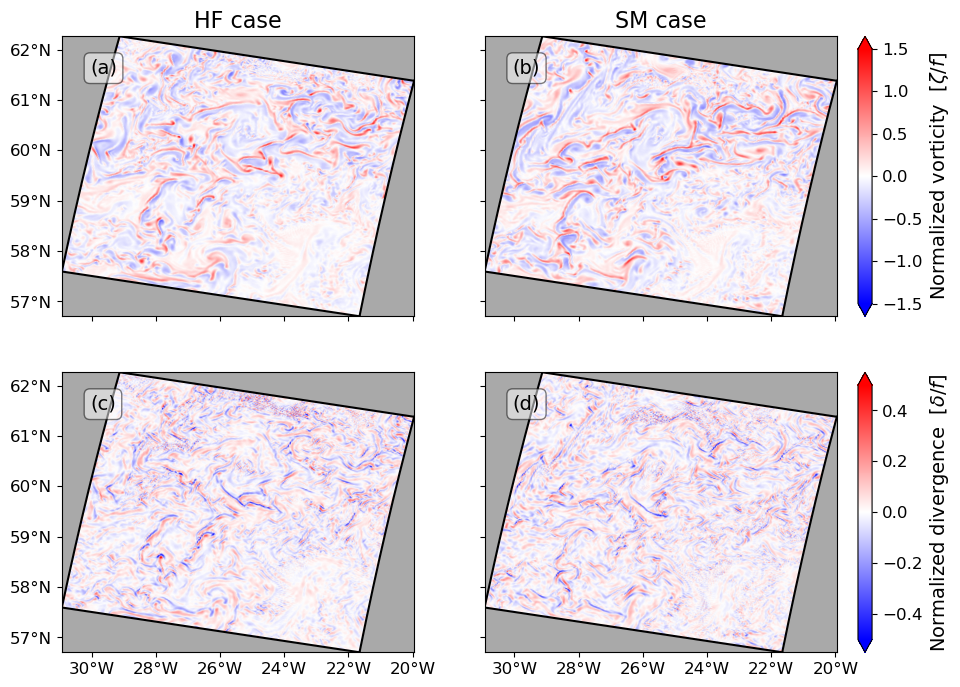

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def format_coordinate(value, coord_type='lon'):
    """
   
    """
    if coord_type == 'lon':
        if value < 0:
            return f'{abs(int(value))}°W' 
        else:
            return f'{int(value)}°E' 
    else: 
        if value < 0:
            return f'{abs(int(value))}°S'  
        else:
            return f'{int(value)}°N'  

#
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

# 创建图形和子图 - 改为2x2的4个子图
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 8))

# 定义一些常量
# pio2 = np.pi/2
# pi3o2 = np.pi*3/2
# xmin, xmax = 0, 2*np.pi  # 假设x轴范围是0到2π

# 第一个子图 (a)
ax1.set_facecolor('darkgrey')
im1 = ax1.pcolormesh(lonr, latr, Ro_w[tindex,:,:], 
                    cmap='bwr', vmin=-1.5, vmax=1.5, shading='gouraud')
ax1.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
ax1.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
ax1.set_xticklabels('')
ax1.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
ax1.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
ax1.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
ax1.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)
ax1.set_title(r'HF case')
ax1.text(0.08, 0.92, '(a)', transform=ax1.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# 第二个子图 (b)
ax2.set_facecolor('darkgrey')
im2 = ax2.pcolormesh(lonr, latr, Ro_nw[tindex,:,:], 
                    cmap='bwr', vmin=-1.5, vmax=1.5, shading='gouraud')
ax2.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
ax2.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
ax2.set_xticklabels('')
ax2.set_yticklabels('')
ax2.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
ax2.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
ax2.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
ax2.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)
ax2.set_title(r'SM case')
ax2.text(0.08, 0.92, '(b)', transform=ax2.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
cax = inset_axes(ax2,
                 width="4%",
                 height="100%",
                 loc='center right',
                 bbox_to_anchor=(0.1, 0, 1, 1),
                 bbox_transform=ax2.transAxes,
                 borderpad=0)
cbar2 = plt.colorbar(im2, cax=cax, orientation='vertical', extend='both')
cbar2.set_label(r'Normalized vorticity  [$\zeta /f$]', fontsize=14)

# 第三个子图 (c)
ax3.set_facecolor('darkgrey')
im3 = ax3.pcolormesh(lonr, latr, divof_w[tindex,:,:], 
                    cmap='bwr', vmin=-0.5, vmax=0.5, shading='gouraud')
ax3.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
ax3.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
ax3.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
ax3.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
ax3.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
ax3.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)
ax3.text(0.08, 0.92, '(c)', transform=ax3.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# 第四个子图 (d)
ax4.set_facecolor('darkgrey')
im4 = ax4.pcolormesh(lonr, latr, divof_nw[tindex,:,:], 
                    cmap='bwr', vmin=-0.5, vmax=0.5, shading='gouraud')
ax4.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
ax4.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
ax4.set_yticklabels('')
ax4.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
ax4.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
ax4.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
ax4.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)

# 
ax4.text(0.08, 0.92, '(d)', transform=ax4.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# 
cax = inset_axes(ax4,
                 width="4%",
                 height="100%",
                 loc='center right',
                 bbox_to_anchor=(0.1, 0, 1, 1),
                 bbox_transform=ax4.transAxes,
                 borderpad=0)
cbar = plt.colorbar(im4, cax=cax, orientation='vertical', extend='both')
cbar.set_label(r'Normalized divergence  [$\delta /f$]', fontsize=14)

# plt.tight_layout()
plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/Fig2_Iceland_vor_div_t=0.png', dpi=300, bbox_inches='tight')
plt.show()

# plot ini position and traj (Rough and smallregion)

In [7]:
#################################rough
w289_r=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P289T89.5days.nc')
lon289_w_r,lat289_w_r=get_traj(w289_r)

w625_r=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P625T89.5days.nc')
lon625_w_r,lat625_w_r=get_traj(w625_r)

w1089_r=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P1089T89.5days.nc')
lon1089_w_r,lat1089_w_r=get_traj(w1089_r)

nw289_r=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/nowave_pars_P289T89.5days.nc')
lon289_nw_r,lat289_nw_r=get_traj(nw289_r)

nw625_r=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/nowave_pars_P625T89.5days.nc')
lon625_nw_r,lat625_nw_r=get_traj(nw625_r)

nw1089_r=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/nowave_pars_P1089T89.5days.nc')
lon1089_nw_r,lat1089_nw_r=get_traj(nw1089_r)

#################################small region
w289_s=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/wave_pars_P289T89.5days.nc')
lon289_w_s,lat289_w_s=get_traj(w289_s)

w625_s=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/wave_pars_P625T89.5days.nc')
lon625_w_s,lat625_w_s=get_traj(w625_s)

w1089_s=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/wave_pars_P1089T89.5days.nc')
lon1089_w_s,lat1089_w_s=get_traj(w1089_s)

nw289_s=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/nowave_pars_P289T89.5days.nc')
lon289_nw_s,lat289_nw_s=get_traj(nw289_s)

nw625_s=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/nowave_pars_P625T89.5days.nc')
lon625_nw_s,lat625_nw_s=get_traj(nw625_s)

nw1089_s=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/nowave_pars_P1089T89.5days.nc')
lon1089_nw_s,lat1089_nw_s=get_traj(nw1089_s)

In [8]:
lon289_nw_r.shape

(289, 2148)

/tmp/ipykernel_1420684/2529135731.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([format_coordinate(x, 'lon') for x in ax.get_xticks()])
/tmp/ipykernel_1420684/2529135731.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([format_coordinate(y, 'lat') for y in ax.get_yticks()])
/tmp/ipykernel_1420684/2529135731.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([format_coordinate(x, 'lon') for x in ax.get_xticks()])
/tmp/ipykernel_1420684/2529135731.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([format_coordinate(y, 'lat') for y in ax.get_yticks()])
/tmp/ipykernel_1

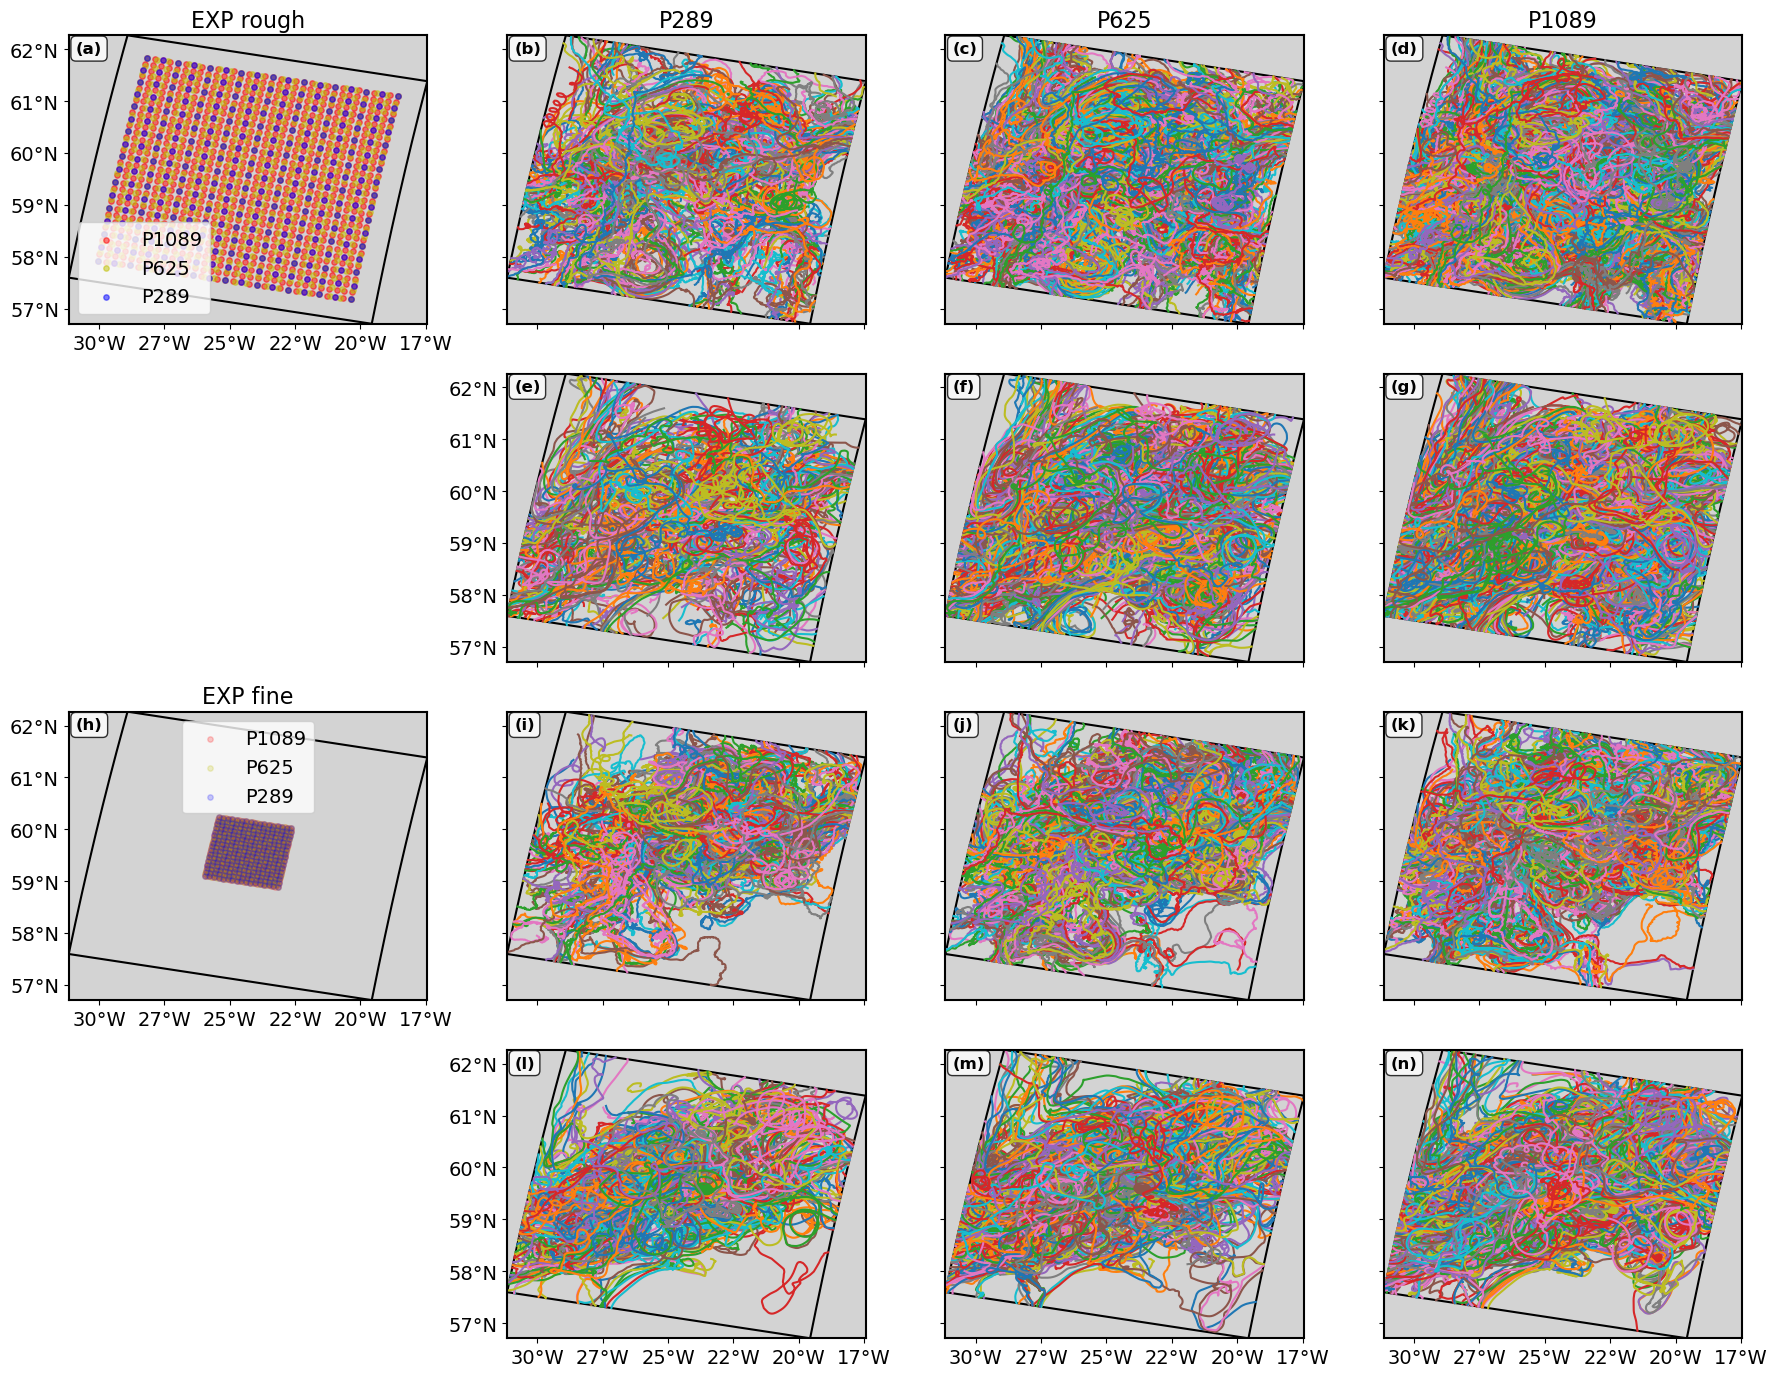

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def format_coordinate(value, coord_type='lon'):
    if coord_type == 'lon':
        if value < 0:
            return f'{abs(int(value))}°W' 
        else:
            return f'{int(value)}°E' 
    else: 
        if value < 0:
            return f'{abs(int(value))}°S'  
        else:
            return f'{int(value)}°N'  

def setup_subplot(ax, label, lonr, latr):
    # 设置背景色
    ax.set_facecolor('lightgray')
    ax.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
    ax.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
    ax.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
    ax.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)
        
    # 设置坐标轴范围
    ax.set_xlim(lonr.min(), lonr.max())
    ax.set_ylim(latr.min(), latr.max())
    
    # 添加经纬度标签
    ax.set_xticklabels([format_coordinate(x, 'lon') for x in ax.get_xticks()])
    ax.set_yticklabels([format_coordinate(y, 'lat') for y in ax.get_yticks()])
    
    # 添加边框
    ax.spines['top'].set_linewidth(1.5)
    ax.spines['right'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    
    # 添加标签
    ax.text(0.02, 0.98, label, transform=ax.transAxes, 
            fontsize=12, va='top', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    return ax

# 设置全局样式
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

# 创建4x4的子图网格
fig, axes = plt.subplots(4, 4, figsize=(18, 14))

# 隐藏第二行和第四行的第一张图
axes[1, 0].set_visible(False)
axes[3, 0].set_visible(False)

# 为每个可见子图创建独立变量
ax1, ax2, ax3, ax4 = axes[0, 0], axes[0, 1], axes[0, 2], axes[0, 3]
ax5, ax6, ax7 = axes[1, 1], axes[1, 2], axes[1, 3]
ax8, ax9, ax10, ax11 = axes[2, 0], axes[2, 1], axes[2, 2], axes[2, 3]
ax12, ax13, ax14 = axes[3, 1], axes[3, 2], axes[3, 3]

# 字母标签
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', 
          '(h)', '(i)', '(j)', '(k)', '(l)', '(m)', '(n)']

# 子图变量列表
ax_list = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12, ax13, ax14]

# 为每个子图设置基本框架
for i, ax in enumerate(ax_list):
    setup_subplot(ax, labels[i], lonr, latr)

# initial distribution
ax1.scatter(lon1089_w_r[:,0],lat1089_w_r[:,0],alpha=0.5,s=15,color='r',label='P1089')
ax1.scatter(lon625_w_r[:,0],lat625_w_r[:,0],alpha=0.5,s=15,color='y',label='P625')
ax1.scatter(lon289_w_r[:,0],lat289_w_r[:,0],alpha=0.5,s=15,color='b',label='P289')
ax1.legend()
ax1.set_title(r'EXP rough')
# ax1.set_xticklabels('')


ax2.plot(lon289_w_r.T,lat289_w_r.T)
ax2.set_xticklabels('')
ax2.set_yticklabels('')
ax2.set_title(r'P289')


ax3.plot(lon625_w_r.T,lat625_w_r.T)
ax3.set_xticklabels('')
ax3.set_yticklabels('')
ax3.set_title(r'P625')


ax4.plot(lon1089_w_r.T,lat1089_w_r.T)
ax4.set_xticklabels('')
ax4.set_yticklabels('')
ax4.set_title(r'P1089')



ax5.plot(lon289_nw_r.T,lat289_nw_r.T)
ax5.set_xticklabels('')

ax6.plot(lon625_nw_r.T,lat625_nw_r.T)
ax6.set_xticklabels('')
ax6.set_yticklabels('')

ax7.plot(lon1089_nw_r.T,lat1089_nw_r.T)
ax7.set_xticklabels('')
ax7.set_yticklabels('')
# 
ax8.scatter(lon1089_w_s[:,0],lat1089_w_s[:,0],alpha=0.2,s=15,color='r',label='P1089')
ax8.scatter(lon625_w_s[:,0],lat625_w_s[:,0],alpha=0.2,s=15,color='y',label='P625')
ax8.scatter(lon289_w_s[:,0],lat289_w_s[:,0],alpha=0.2,s=15,color='b',label='P289')
ax8.legend()
ax8.set_title(r'EXP fine')


ax9.plot(lon289_w_s.T,lat289_w_s.T)
ax9.set_xticklabels('')
ax9.set_yticklabels('')

ax10.plot(lon625_w_s.T,lat625_w_s.T)
ax10.set_xticklabels('')
ax10.set_yticklabels('')

ax11.plot(lon1089_w_s.T,lat1089_w_s.T)
ax11.set_xticklabels('')
ax11.set_yticklabels('')


ax12.plot(lon289_nw_s.T,lat289_nw_s.T)
# ax12.set_xticklabels('')
# ax12.set_yticklabels('')

ax13.plot(lon625_nw_s.T,lat625_nw_s.T)
# ax13.set_xticklabels('')
ax13.set_yticklabels('')

ax14.plot(lon1089_nw_s.T,lat1089_nw_s.T)
# ax14.set_xticklabels('')
ax14.set_yticklabels('')

plt.tight_layout()
plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/Fig3_Iceland_traj_rough_roughsmallregion.png', dpi=300, bbox_inches='tight')

plt.show()